In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

final_test_results = pd.read_csv(
    "final_forecasting_test_results.csv"
)

ablation_results = pd.read_csv(
    "forecasting_ablation_results_360.csv"
)

validation_test_comparison = pd.read_csv(
    "forecasting_validation_test_comparison.csv"
)

test_final = pd.read_pickle(
    "final_forecasting_test_dataset.pkl"
)

final_forecasting_models = joblib.load(
    "final_player_forecasting_models.pkl"
)

selected_forecasting_models = joblib.load(
    "selected_forecasting_models.pkl"
)

xpass_model = joblib.load(
    "xpass_event_360_model.pkl"
)

print("Final test results:", final_test_results.shape)
print("Ablation results:", ablation_results.shape)
print(
    "Validation/test comparison:",
    validation_test_comparison.shape
)
print("Final test dataset:", test_final.shape)

display(final_test_results)

Final test results: (5, 7)
Ablation results: (60, 6)
Validation/test comparison: (5, 9)
Final test dataset: (1928, 92)


,target,configuration,algorithm,test_rows,MAE,RMSE,R2
0,second_half_actions_per90,G_History_FirstHalf_xPass_Trajectory,Random Forest,1928,33.872849,44.941371,0.498625
1,second_half_miscontrols_per90,E_History_FirstHalf,Linear Regression,1928,1.084323,1.556711,0.156465
2,second_half_pass_completion_rate,F_History_FirstHalf_xPass,Linear Regression,1928,0.099574,0.133431,0.249906
3,second_half_progressive_passes_per90,E_History_FirstHalf,Linear Regression,1928,3.687386,4.852344,0.317712
4,second_half_statsbomb_xg_per90,E_History_FirstHalf,Linear Regression,1928,0.143026,0.300463,0.123944


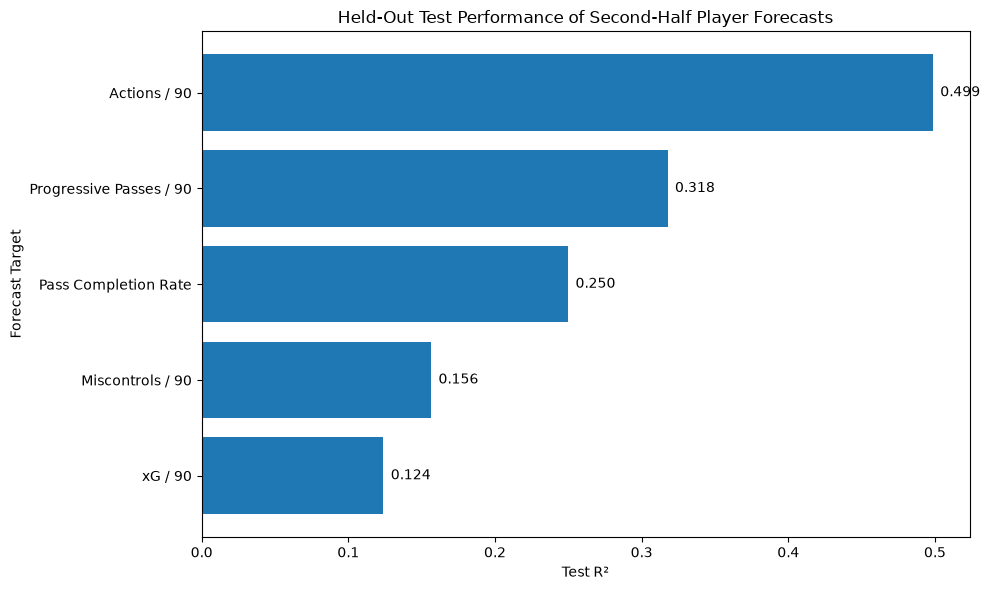

In [2]:
target_labels = {
    "second_half_actions_per90": "Actions / 90",
    "second_half_progressive_passes_per90": "Progressive Passes / 90",
    "second_half_pass_completion_rate": "Pass Completion Rate",
    "second_half_miscontrols_per90": "Miscontrols / 90",
    "second_half_statsbomb_xg_per90": "xG / 90"
}

plot_results = final_test_results.copy()

plot_results["target_label"] = (
    plot_results["target"]
    .map(target_labels)
)

plot_results = plot_results.sort_values(
    "R2",
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_results["target_label"],
    plot_results["R2"]
)

plt.xlabel("Test R²")
plt.ylabel("Forecast Target")
plt.title(
    "Held-Out Test Performance of Second-Half Player Forecasts"
)

for bar, value in zip(
    bars,
    plot_results["R2"]
):
    plt.text(
        value + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "forecasting_test_r2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

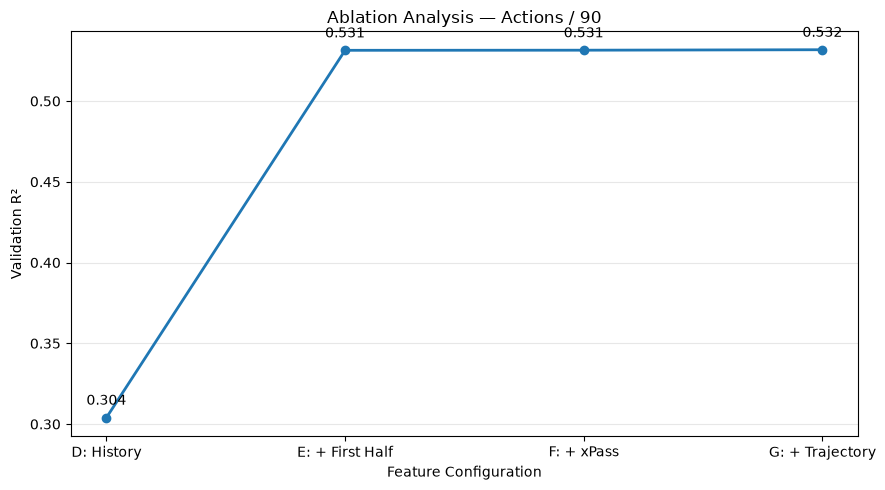

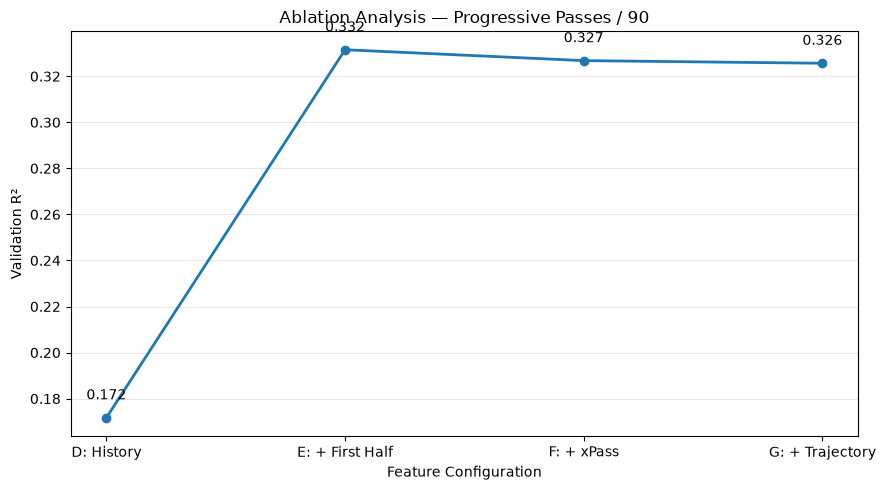

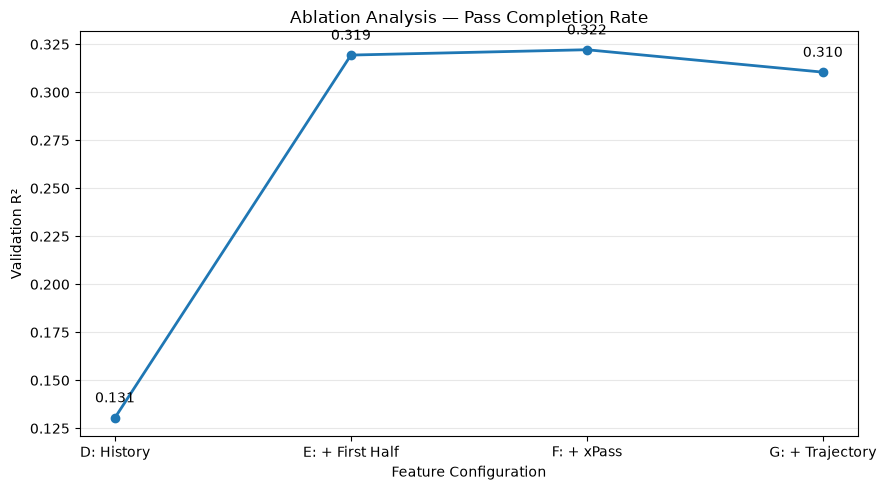

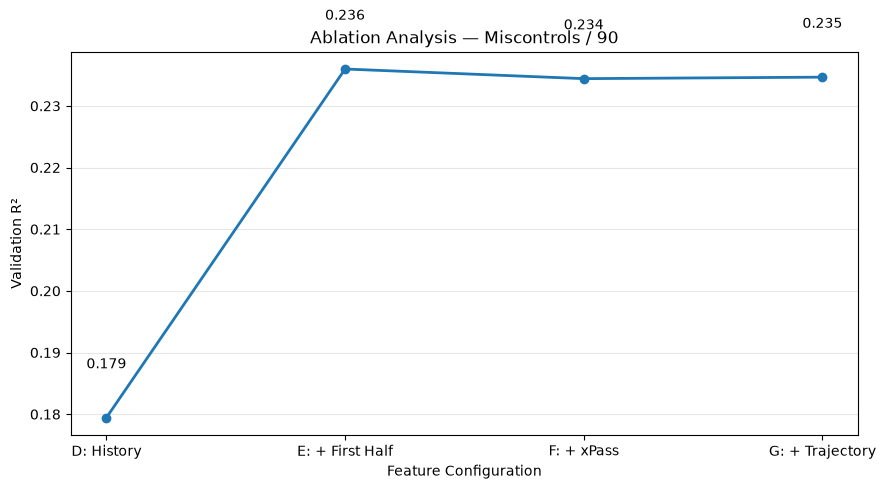

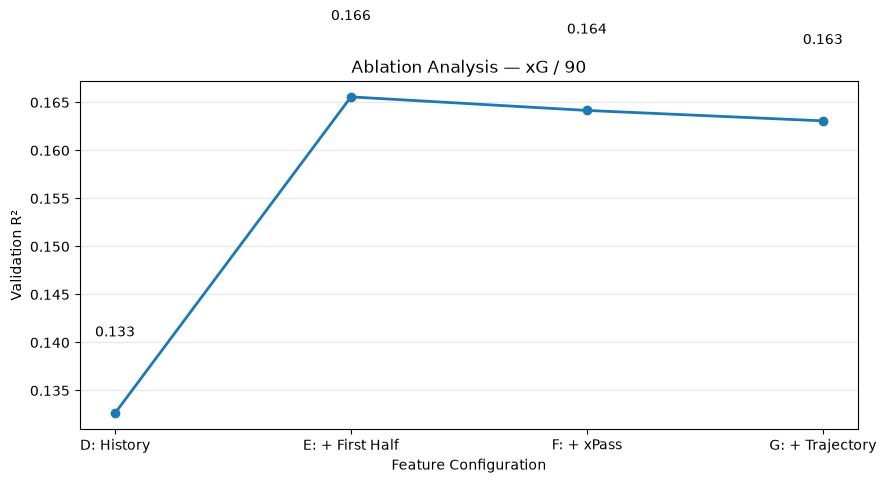

In [3]:
config_labels = {
    "D_History": "D: History",
    "E_History_FirstHalf": "E: + First Half",
    "F_History_FirstHalf_xPass": "F: + xPass",
    "G_History_FirstHalf_xPass_Trajectory": "G: + Trajectory"
}

ablation_best = (
    ablation_results
    .sort_values("R2", ascending=False)
    .groupby(
        ["target", "configuration"],
        as_index=False
    )
    .first()
)

ablation_best["target_label"] = (
    ablation_best["target"].map(target_labels)
)

ablation_best["config_label"] = (
    ablation_best["configuration"].map(config_labels)
)

config_order = [
    "D: History",
    "E: + First Half",
    "F: + xPass",
    "G: + Trajectory"
]

for target in target_labels.values():

    target_data = ablation_best[
        ablation_best["target_label"] == target
    ].copy()

    target_data["config_label"] = pd.Categorical(
        target_data["config_label"],
        categories=config_order,
        ordered=True
    )

    target_data = target_data.sort_values(
        "config_label"
    )

    plt.figure(figsize=(9, 5))

    plt.plot(
        target_data["config_label"],
        target_data["R2"],
        marker="o",
        linewidth=2
    )

    for x, y in zip(
        target_data["config_label"],
        target_data["R2"]
    ):
        plt.text(
            x,
            y + 0.008,
            f"{y:.3f}",
            ha="center"
        )

    plt.ylabel("Validation R²")
    plt.xlabel("Feature Configuration")

    plt.title(
        f"Ablation Analysis — {target}"
    )

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    filename = (
        "ablation_"
        + target.lower()
        .replace(" ", "_")
        .replace("/", "per")
        + ".png"
    )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

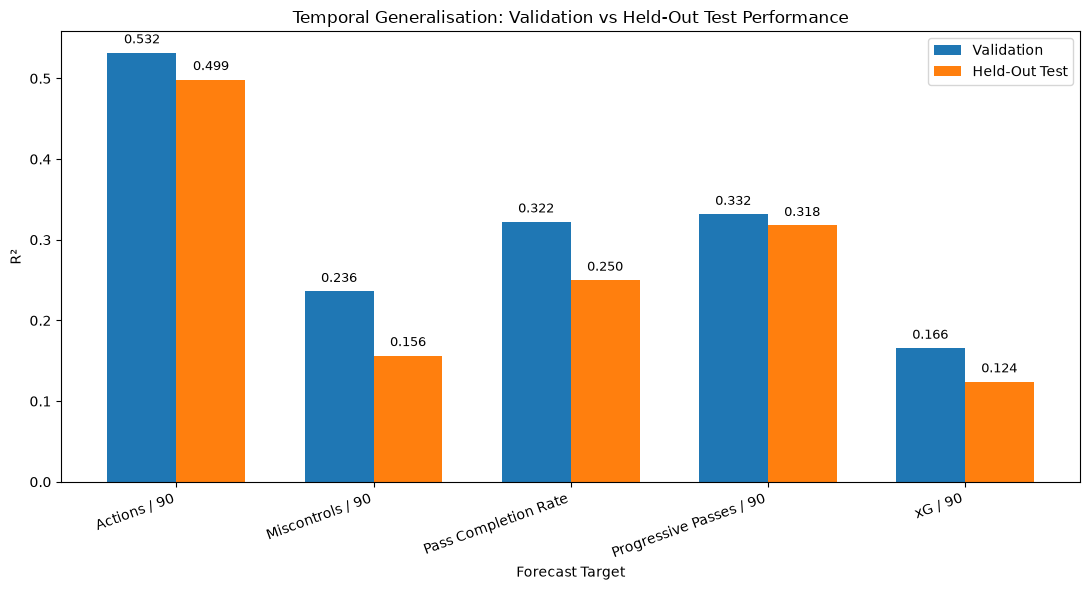

In [4]:
comparison_plot = validation_test_comparison.copy()

comparison_plot["target_label"] = (
    comparison_plot["target"]
    .map(target_labels)
)

x = np.arange(
    len(comparison_plot)
)

width = 0.35

plt.figure(figsize=(11, 6))

validation_bars = plt.bar(
    x - width / 2,
    comparison_plot["validation_R2"],
    width,
    label="Validation"
)

test_bars = plt.bar(
    x + width / 2,
    comparison_plot["test_R2"],
    width,
    label="Held-Out Test"
)

plt.xticks(
    x,
    comparison_plot["target_label"],
    rotation=20,
    ha="right"
)

plt.ylabel("R²")
plt.xlabel("Forecast Target")

plt.title(
    "Temporal Generalisation: Validation vs Held-Out Test Performance"
)

plt.legend()

for bars in [
    validation_bars,
    test_bars
]:
    for bar in bars:
        value = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.008,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    "forecasting_validation_vs_test_r2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
history_like_columns = [
    col for col in test_final.columns
    if (
        "previous" in col.lower()
        or "last3" in col.lower()
        or "last5" in col.lower()
    )
]

print("Historical-looking columns:")
for col in history_like_columns:
    print(col)

Historical-looking columns:
previous_matches_available
previous_reliable_pass_attempts_per90
previous_reliable_progressive_passes_per90
previous_reliable_carries_per90
previous_reliable_shots_per90
previous_reliable_miscontrols_per90
previous_reliable_shot_assists_per90


In [8]:
for target, model in final_forecasting_models.items():

    print("\nTARGET:", target)

    if hasattr(model, "feature_names_in_"):
        print(list(model.feature_names_in_))
    else:
        print("No feature_names_in_ stored")


TARGET: second_half_actions_per90
['previous_matches_available', 'previous_reliable_pass_attempts_per90', 'previous_reliable_progressive_passes_per90', 'previous_reliable_carries_per90', 'previous_reliable_shots_per90', 'previous_reliable_miscontrols_per90', 'previous_reliable_shot_assists_per90', 'last_3_reliable_pass_attempts_per90', 'last_3_reliable_progressive_passes_per90', 'last_3_reliable_carries_per90', 'last_3_reliable_shots_per90', 'last_3_reliable_miscontrols_per90', 'last_3_reliable_shot_assists_per90', 'first_half_actions_per90', 'first_half_pass_attempts_per90', 'first_half_completed_passes_per90', 'first_half_progressive_passes_per90', 'first_half_pass_completion_rate', 'first_half_shots_per90', 'first_half_statsbomb_xg_per90', 'first_half_carries_per90', 'first_half_miscontrols_per90', 'first_half_interceptions_per90', 'first_half_ball_recoveries_per90', 'first_half_dribbles_per90', 'first_half_duels_per90', 'first_half_pressures_per90', 'first_half_shot_assists_per90'

In [9]:
prediction_results = test_final[
    ["match_id", "player_id"]
].copy()

for target, model in final_forecasting_models.items():

    features = list(
        model.feature_names_in_
    )

    missing_features = [
        feature
        for feature in features
        if feature not in test_final.columns
    ]

    if missing_features:
        raise ValueError(
            f"Missing features for {target}: "
            f"{missing_features}"
        )

    prediction_results[
        f"actual_{target}"
    ] = test_final[target].values

    prediction_results[
        f"predicted_{target}"
    ] = model.predict(
        test_final[features]
    )

print(
    "Prediction rows:",
    len(prediction_results)
)

print(
    "Matches:",
    prediction_results[
        "match_id"
    ].nunique()
)

print(
    "Players:",
    prediction_results[
        "player_id"
    ].nunique()
)

print(
    "Missing prediction values:",
    prediction_results.isna().sum().sum()
)

display(
    prediction_results.head()
)

Prediction rows: 1928
Matches: 101
Players: 733
Missing prediction values: 0


,match_id,player_id,actual_second_half_actions_per90,predicted_second_half_actions_per90,actual_second_half_miscontrols_per90,predicted_second_half_miscontrols_per90,actual_second_half_pass_completion_rate,predicted_second_half_pass_completion_rate,actual_second_half_progressive_passes_per90,predicted_second_half_progressive_passes_per90,actual_second_half_statsbomb_xg_per90,predicted_second_half_statsbomb_xg_per90
0,3895194,3500,344.568063,288.094384,1.767016,1.006598,0.969231,0.914423,8.835079,10.198977,0.126724,0.166618
1,3895194,6874,124.197413,123.480512,2.587446,1.957978,0.666667,0.637528,2.587446,6.852418,0.269280,0.103674
2,3895194,7044,111.321990,112.461810,3.534031,2.326653,1.000000,0.755273,0.000000,1.809326,0.589975,0.349508
3,3895194,8056,103.646833,126.034459,0.000000,1.075792,0.625000,0.703468,2.591171,7.368153,0.000000,0.027288
4,3895194,8245,60.078534,139.901260,0.000000,1.059480,0.923077,0.771669,7.068063,7.064252,0.000000,0.068547


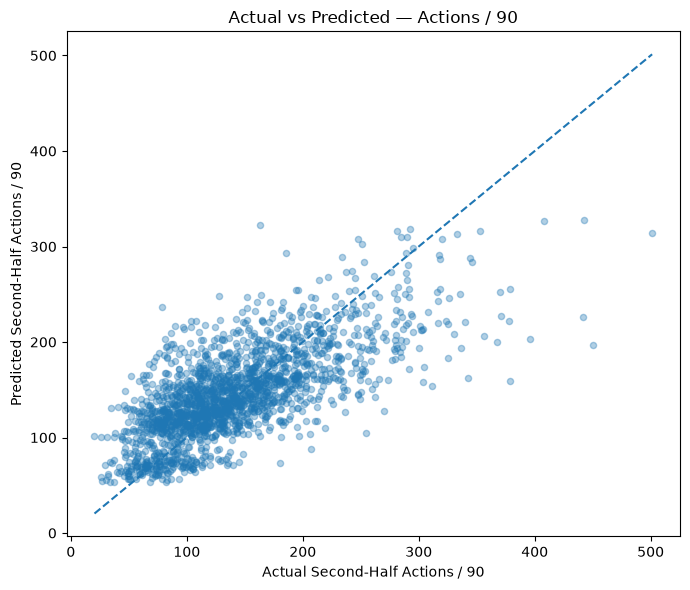

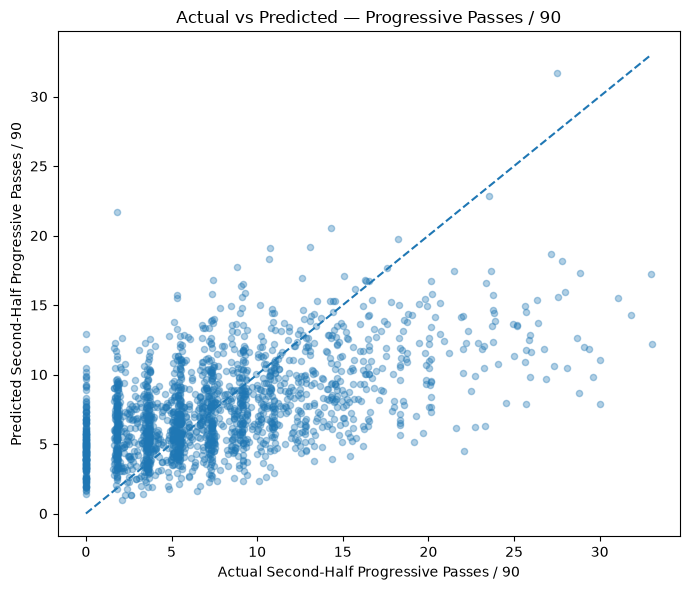

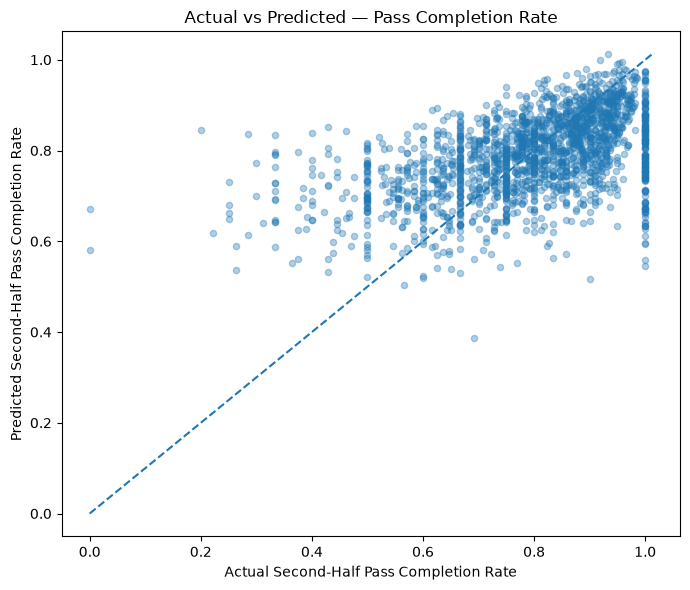

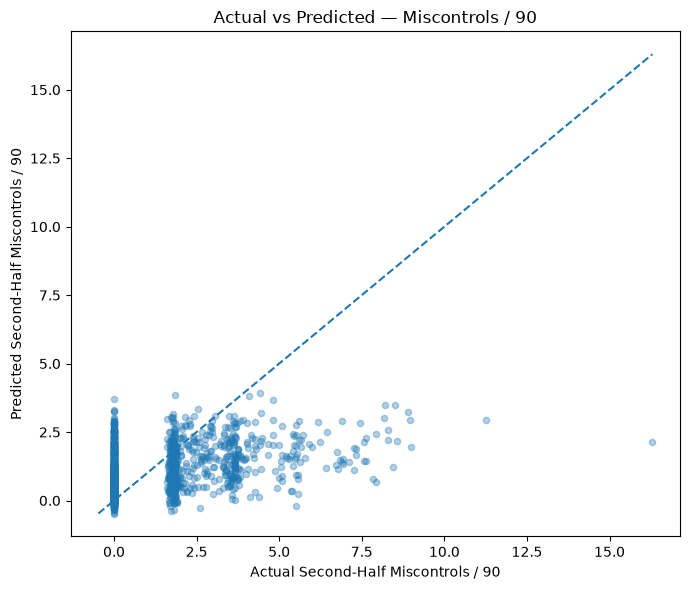

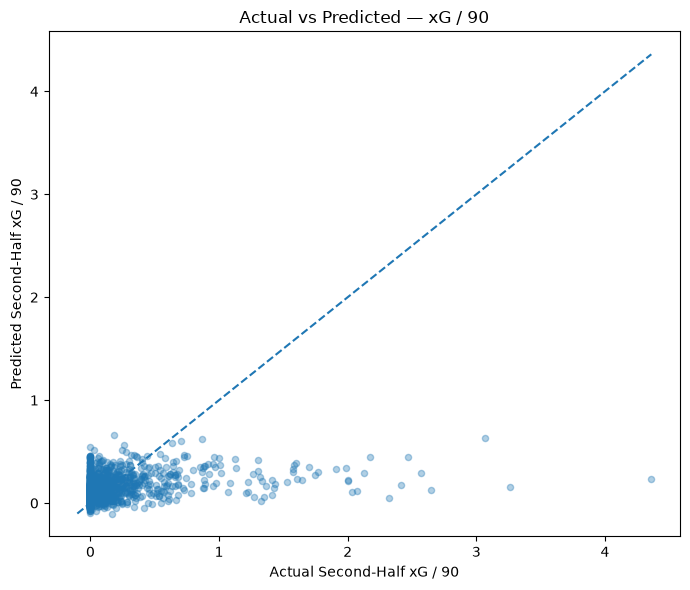

In [10]:
for target, label in target_labels.items():

    actual_col = f"actual_{target}"
    predicted_col = f"predicted_{target}"

    actual = prediction_results[
        actual_col
    ]

    predicted = prediction_results[
        predicted_col
    ]

    minimum = min(
        actual.min(),
        predicted.min()
    )

    maximum = max(
        actual.max(),
        predicted.max()
    )

    plt.figure(figsize=(7, 6))

    plt.scatter(
        actual,
        predicted,
        alpha=0.35,
        s=20
    )

    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

    plt.xlabel(
        f"Actual Second-Half {label}"
    )

    plt.ylabel(
        f"Predicted Second-Half {label}"
    )

    plt.title(
        f"Actual vs Predicted — {label}"
    )

    plt.tight_layout()

    filename = (
        "actual_vs_predicted_"
        + label.lower()
        .replace(" ", "_")
        .replace("/", "per")
        + ".png"
    )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [11]:
residual_summary = []

for target, label in target_labels.items():

    actual = prediction_results[
        f"actual_{target}"
    ]

    predicted = prediction_results[
        f"predicted_{target}"
    ]

    residual = actual - predicted

    prediction_results[
        f"residual_{target}"
    ] = residual

    residual_summary.append({
        "target": label,
        "mean_residual": residual.mean(),
        "median_residual": residual.median(),
        "mean_absolute_error": np.abs(residual).mean(),
        "residual_std": residual.std(),
        "underpredicted_percentage":
            (residual > 0).mean() * 100,
        "overpredicted_percentage":
            (residual < 0).mean() * 100
    })

residual_summary = pd.DataFrame(
    residual_summary
)

display(
    residual_summary.round(4)
)

residual_summary.to_csv(
    "forecasting_residual_summary.csv",
    index=False
)

,target,mean_residual,median_residual,mean_absolute_error,residual_std,underpredicted_percentage,overpredicted_percentage
0,Actions / 90,-4.8234,-6.5574,33.8728,44.6934,43.1535,56.8465
1,Progressive Passes / 90,0.0146,-0.5925,3.6874,4.8536,44.0871,55.9129
2,Pass Completion Rate,0.0019,0.0098,0.0996,0.1335,54.2531,45.7469
3,Miscontrols / 90,-0.0222,-0.3097,1.0843,1.5570,32.8838,67.1162
4,xG / 90,0.0016,-0.0429,0.1430,0.3005,27.5415,72.4585


In [12]:
largest_errors = {}

for target, label in target_labels.items():

    actual_col = f"actual_{target}"
    predicted_col = f"predicted_{target}"

    error_data = prediction_results[
        [
            "match_id",
            "player_id",
            actual_col,
            predicted_col
        ]
    ].copy()

    error_data["absolute_error"] = np.abs(
        error_data[actual_col]
        - error_data[predicted_col]
    )

    error_data = (
        error_data
        .sort_values(
            "absolute_error",
            ascending=False
        )
        .head(10)
    )

    largest_errors[target] = error_data

    print("\n", label)
    display(error_data)


 Actions / 90


,match_id,player_id,actual_second_half_actions_per90,predicted_second_half_actions_per90,absolute_error
1115,3941018,6655,450.419385,197.153095,253.266290
1070,3940878,38909,378.947368,159.564614,219.382754
1120,3941018,17620,441.700080,226.655141,215.044939
1754,3998858,18999,395.821530,202.914620,192.906910
158,3895266,3500,501.257396,314.080027,187.177369
1061,3940878,6993,342.906178,162.114489,180.791689
143,3895258,8221,367.755386,199.881455,167.873931
188,3895275,38004,163.025780,322.735672,159.709892
147,3895258,9195,311.466296,153.438318,158.027978
290,3895320,95272,78.508217,236.406573,157.898355



 Progressive Passes / 90


,match_id,player_id,actual_second_half_progressive_passes_per90,predicted_second_half_progressive_passes_per90,absolute_error
7,3895194,8804,30.039267,7.883466,22.155801
469,3930163,3468,33.038749,12.195456,20.843293
1192,3941022,8518,28.790403,8.682691,20.107712
66,3895220,8919,1.831750,21.664588,19.832838
1824,4018355,62667,29.629630,9.811782,19.817848
17,3895194,37005,30.039267,11.015085,19.024182
1573,3998848,46873,25.679348,7.900565,17.778783
1450,3998841,62667,28.099174,10.492890,17.606284
504,3930164,114832,22.061596,4.498451,17.563146
800,3930180,9731,29.357211,11.810577,17.546635



 Pass Completion Rate


,match_id,player_id,actual_second_half_pass_completion_rate,predicted_second_half_pass_completion_rate,absolute_error
1421,3998840,25476,0.000000,0.670698,0.670698
1759,3998858,84765,0.200000,0.845102,0.645102
1491,3998844,10134,0.000000,0.580132,0.580132
579,3930168,89635,0.285714,0.836980,0.551266
1511,3998845,13713,0.333333,0.835237,0.501904
1863,4018357,47006,0.250000,0.729650,0.479650
1819,4018355,26094,0.300000,0.771911,0.471911
1044,3938645,25079,0.333333,0.796338,0.463004
1592,3998849,32227,0.333333,0.792657,0.459324
458,3930162,31089,0.333333,0.790252,0.456919



 Miscontrols / 90


,match_id,player_id,actual_second_half_miscontrols_per90,predicted_second_half_miscontrols_per90,absolute_error
1669,3998853,87194,16.294508,2.153703,14.140805
1234,3942227,5545,11.265647,2.941785,8.323862
390,3930159,7796,7.923698,0.662435,7.261262
69,3895220,9222,8.450704,1.207228,7.243476
284,3895320,28805,7.826087,0.780794,7.045293
1761,3998858,322359,8.977556,1.942228,7.035328
1352,3998836,190348,8.557845,2.191161,6.366683
51,3895210,10336,7.277628,1.098111,6.179517
313,3895340,7044,7.616361,1.459562,6.156799
1088,3940983,17042,7.557733,1.427688,6.130045



 xG / 90


,match_id,player_id,actual_second_half_statsbomb_xg_per90,predicted_second_half_statsbomb_xg_per90,absolute_error
1362,3998837,10385,4.360327,0.237332,4.122996
758,3930178,5463,3.259535,0.154263,3.105273
911,3938638,31193,2.649125,0.124944,2.524181
978,3938642,7044,3.065431,0.629046,2.436385
268,3895309,41411,2.569654,0.293214,2.276440
1607,3998850,10272,2.319275,0.046548,2.272727
406,3930160,5460,2.412588,0.172208,2.240379
1085,3940983,8966,2.470047,0.451308,2.018739
1635,3998851,31534,2.070057,0.119173,1.950884
1771,3998859,15470,2.035017,0.106993,1.928025


In [13]:
history_error_results = []

for target, label in target_labels.items():

    actual = prediction_results[
        f"actual_{target}"
    ]

    predicted = prediction_results[
        f"predicted_{target}"
    ]

    analysis = pd.DataFrame({
        "absolute_error": np.abs(
            actual - predicted
        ),
        "previous_matches_available":
            test_final[
                "previous_matches_available"
            ].values
    })

    analysis["history_group"] = pd.cut(
        analysis["previous_matches_available"],
        bins=[
            -1,
            0,
            2,
            5,
            10,
            np.inf
        ],
        labels=[
            "0",
            "1–2",
            "3–5",
            "6–10",
            "11+"
        ]
    )

    grouped = (
        analysis
        .groupby(
            "history_group",
            observed=True
        )
        .agg(
            observations=(
                "absolute_error",
                "size"
            ),
            mean_absolute_error=(
                "absolute_error",
                "mean"
            ),
            median_absolute_error=(
                "absolute_error",
                "median"
            )
        )
        .reset_index()
    )

    grouped["target"] = label

    history_error_results.append(
        grouped
    )

history_error_results = pd.concat(
    history_error_results,
    ignore_index=True
)

display(
    history_error_results[
        [
            "target",
            "history_group",
            "observations",
            "mean_absolute_error",
            "median_absolute_error"
        ]
    ].round(4)
)

history_error_results.to_csv(
    "forecasting_error_by_history.csv",
    index=False
)

,target,history_group,observations,mean_absolute_error,median_absolute_error
0,Actions / 90,0,144,30.9782,27.2541
1,Actions / 90,1–2,340,33.4046,27.5548
2,Actions / 90,3–5,265,32.4026,25.3619
3,Actions / 90,6–10,231,36.5413,27.7116
4,Actions / 90,11+,948,34.2412,26.0090
5,Progressive Passes / 90,0,144,3.9745,3.0033
6,Progressive Passes / 90,1–2,340,3.8684,2.8718
7,Progressive Passes / 90,3–5,265,3.4886,2.8505
8,Progressive Passes / 90,6–10,231,3.6949,3.1828
9,Progressive Passes / 90,11+,948,3.6326,3.0368


In [14]:
extreme_error_results = []

for target, label in target_labels.items():

    actual = prediction_results[
        f"actual_{target}"
    ]

    predicted = prediction_results[
        f"predicted_{target}"
    ]

    analysis = pd.DataFrame({
        "actual": actual,
        "predicted": predicted
    })

    analysis["absolute_error"] = np.abs(
        analysis["actual"]
        - analysis["predicted"]
    )

    analysis["actual_group"] = pd.qcut(
        analysis["actual"],
        q=5,
        duplicates="drop"
    )

    grouped = (
        analysis
        .groupby(
            "actual_group",
            observed=True
        )
        .agg(
            observations=("actual", "size"),
            mean_actual=("actual", "mean"),
            mean_predicted=("predicted", "mean"),
            mean_absolute_error=("absolute_error", "mean")
        )
        .reset_index()
    )

    grouped["target"] = label

    extreme_error_results.append(
        grouped
    )

extreme_error_results = pd.concat(
    extreme_error_results,
    ignore_index=True
)

display(
    extreme_error_results[
        [
            "target",
            "actual_group",
            "observations",
            "mean_actual",
            "mean_predicted",
            "mean_absolute_error"
        ]
    ].round(4)
)

extreme_error_results.to_csv(
    "forecasting_error_by_actual_performance.csv",
    index=False
)

,target,actual_group,observations,mean_actual,mean_predicted,mean_absolute_error
0,Actions / 90,"(20.389999999999997, 87.661]",386,68.5513,104.8784,39.0650
1,Actions / 90,"(87.661, 115.162]",386,102.1430,126.0489,31.5829
2,Actions / 90,"(115.162, 143.518]",385,129.0479,139.6314,22.9731
3,Actions / 90,"(143.518, 185.685]",385,163.7559,160.3608,25.2545
4,Actions / 90,"(185.685, 501.257]",386,239.6865,196.3757,50.4382
5,Progressive Passes / 90,"(-0.001, 2.404]",386,0.9681,5.5472,4.5907
6,Progressive Passes / 90,"(2.404, 5.274]",385,3.8563,5.9587,2.4063
7,Progressive Passes / 90,"(5.274, 7.347]",387,6.2527,7.0691,2.1075
8,Progressive Passes / 90,"(7.347, 11.266]",386,9.3304,8.1494,2.6895
9,Progressive Passes / 90,"(11.266, 33.039]",384,16.8007,10.3810,6.6591


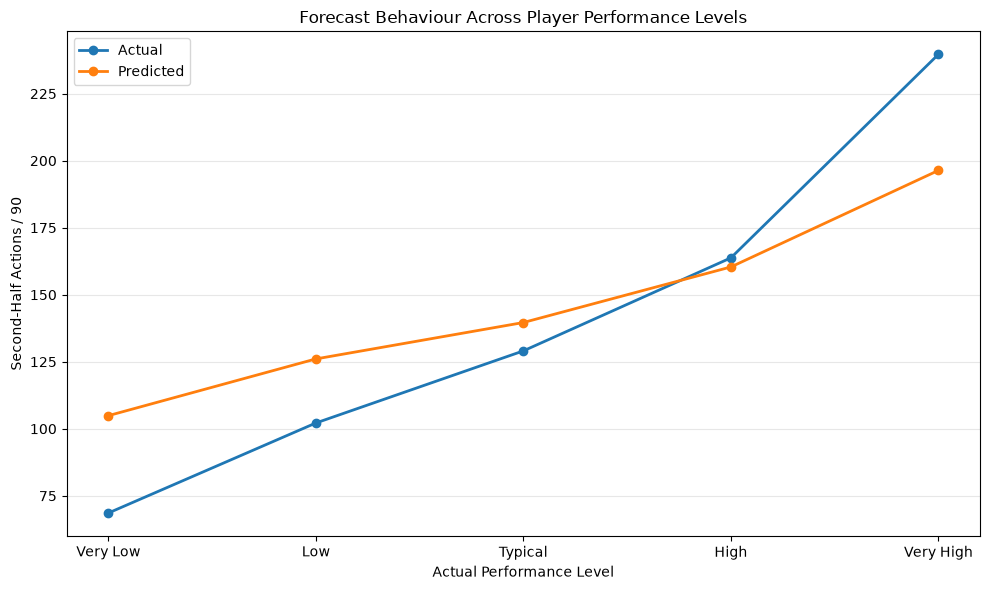

In [15]:
actions_extreme = extreme_error_results[
    extreme_error_results["target"] == "Actions / 90"
].copy()

performance_labels = [
    "Very Low",
    "Low",
    "Typical",
    "High",
    "Very High"
]

actions_extreme["performance_level"] = (
    performance_labels[
        :len(actions_extreme)
    ]
)

x = np.arange(
    len(actions_extreme)
)

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    actions_extreme["mean_actual"],
    marker="o",
    linewidth=2,
    label="Actual"
)

plt.plot(
    x,
    actions_extreme["mean_predicted"],
    marker="o",
    linewidth=2,
    label="Predicted"
)

plt.xticks(
    x,
    actions_extreme["performance_level"]
)

plt.xlabel("Actual Performance Level")
plt.ylabel("Second-Half Actions / 90")

plt.title(
    "Forecast Behaviour Across Player Performance Levels"
)

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "forecast_regression_to_mean_actions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
pass_data = pd.read_pickle(
    "final_pass_modelling_dataset.pkl"
)

print("Pass dataset shape:", pass_data.shape)

print("\nAvailable columns:")
print(pass_data.columns.tolist())

Pass dataset shape: (447122, 41)

Available columns:
['match_id', 'id', 'player_id', 'player_name', 'match_date', 'pass_completed', 'pass_length', 'pass_angle_degrees', 'start_x', 'start_y', 'is_cross', 'is_through_ball', 'is_switch', 'nearest_opponent_distance', 'nearest_teammate_distance', 'under_spatial_pressure', 'nearby_opponents_5', 'nearby_teammates_5', 'local_numerical_balance_5', 'nearby_opponents_10', 'nearby_teammates_10', 'local_numerical_balance_10', 'prev_pass_completion_rate', 'rolling_3_pass_completion', 'rolling_5_pass_completion', 'prev_pass_attempts', 'rolling_3_pass_attempts', 'rolling_5_pass_attempts', 'previous_matches_available', 'previous_reliable_pass_attempts_per90', 'previous_reliable_progressive_passes_per90', 'previous_reliable_carries_per90', 'previous_reliable_shots_per90', 'previous_reliable_miscontrols_per90', 'previous_reliable_shot_assists_per90', 'end_x', 'end_y', 'forward_distance', 'goal_distance_reduction_pct', 'is_forward_pass', 'is_progressive_p

In [17]:
pass_data["match_date"] = pd.to_datetime(
    pass_data["match_date"],
    errors="coerce"
)

xpass_event_features = [
    "pass_length",
    "pass_angle_degrees",
    "start_x",
    "start_y",
    "is_cross",
    "is_through_ball",
    "is_switch"
]

xpass_360_features = [
    "nearest_opponent_distance",
    "nearest_teammate_distance",
    "under_spatial_pressure",
    "nearby_opponents_5",
    "nearby_teammates_5",
    "local_numerical_balance_5",
    "nearby_opponents_10",
    "nearby_teammates_10",
    "local_numerical_balance_10"
]

xpass_full_features = (
    xpass_event_features
    + xpass_360_features
)

xpass_train = pass_data[
    pass_data["match_date"]
    <= "2022-12-31"
].copy()

xpass_validation = pass_data[
    pass_data["match_date"].dt.year
    == 2023
].copy()

xpass_test = pass_data[
    pass_data["match_date"]
    >= "2024-01-01"
].copy()

print("Train passes:", len(xpass_train))
print("Validation passes:", len(xpass_validation))
print("Test passes:", len(xpass_test))

print("\nTest matches:", xpass_test["match_id"].nunique())
print("Test players:", xpass_test["player_id"].nunique())

print(
    "\nTest completion rate:",
    xpass_test["pass_completed"].mean()
)

Train passes: 236016
Validation passes: 106801
Test passes: 104305

Test matches: 101
Test players: 1063

Test completion rate: 0.8248214371314894


In [19]:
X_xpass_test = (
    xpass_test[
        xpass_full_features
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .astype(float)
)

y_xpass_test = (
    xpass_test[
        "pass_completed"
    ]
    .astype(int)
)

print(
    "Missing feature values:",
    X_xpass_test.isna().sum().sum()
)

xpass_probabilities = (
    xpass_model.predict_proba(
        X_xpass_test
    )[:, 1]
)

xpass_predictions = (
    xpass_probabilities >= 0.5
).astype(int)

Missing feature values: 169249


In [20]:
accuracy = accuracy_score(
    y_xpass_test,
    xpass_predictions
)

precision = precision_score(
    y_xpass_test,
    xpass_predictions
)

recall = recall_score(
    y_xpass_test,
    xpass_predictions
)

f1 = f1_score(
    y_xpass_test,
    xpass_predictions
)

auc = roc_auc_score(
    y_xpass_test,
    xpass_probabilities
)

logloss = log_loss(
    y_xpass_test,
    xpass_probabilities
)

brier = brier_score_loss(
    y_xpass_test,
    xpass_probabilities
)

cm = confusion_matrix(
    y_xpass_test,
    xpass_predictions
)

tn, fp, fn, tp = cm.ravel()

specificity = tn / (
    tn + fp
)

xpass_test_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1",
        "ROC-AUC",
        "Log Loss",
        "Brier Score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        specificity,
        f1,
        auc,
        logloss,
        brier
    ]
})

display(
    xpass_test_metrics.round(4)
)

print("\nConfusion Matrix:")
print(cm)

,Metric,Value
0,Accuracy,0.8808
1,Precision,0.9108
2,Recall,0.9483
3,Specificity,0.5629
4,F1,0.9292
5,ROC-AUC,0.9107
6,Log Loss,0.2708
7,Brier Score,0.0841



Confusion Matrix:
[[10285  7987]
 [ 4449 81584]]


In [21]:
xpass_360_comparison = pd.DataFrame({
    "Configuration": [
        "Event Only",
        "Event + 360"
    ],
    "ROC_AUC": [
        0.8886,
        0.9122
    ],
    "Log_Loss": [
        0.2810,
        0.2569
    ],
    "Brier_Score": [
        0.0846,
        0.0785
    ]
})

xpass_360_comparison["AUC_change_vs_event_only"] = [
    0,
    (
        xpass_360_comparison.loc[1, "ROC_AUC"]
        - xpass_360_comparison.loc[0, "ROC_AUC"]
    )
]

display(
    xpass_360_comparison.round(4)
)

xpass_360_comparison.to_csv(
    "xpass_event_vs_360_comparison.csv",
    index=False
)

,Configuration,ROC_AUC,Log_Loss,Brier_Score,AUC_change_vs_event_only
0,Event Only,0.8886,0.2810,0.0846,0.0000
1,Event + 360,0.9122,0.2569,0.0785,0.0236


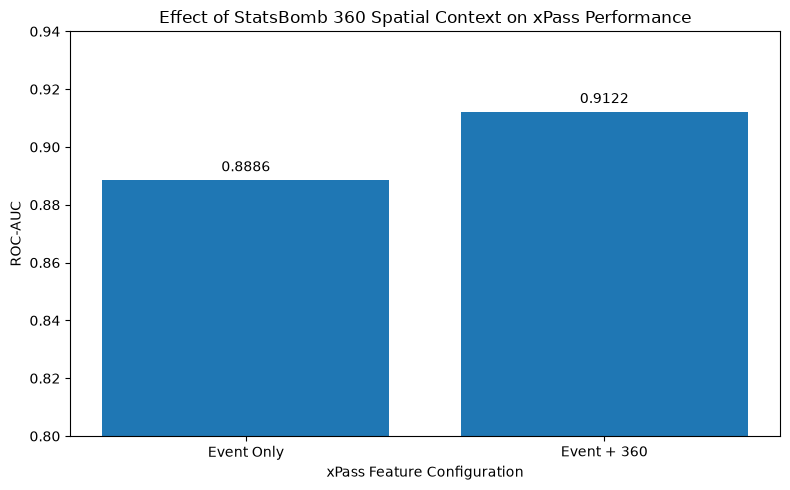

In [22]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    xpass_360_comparison["Configuration"],
    xpass_360_comparison["ROC_AUC"]
)

plt.ylabel("ROC-AUC")
plt.xlabel("xPass Feature Configuration")

plt.title(
    "Effect of StatsBomb 360 Spatial Context on xPass Performance"
)

plt.ylim(0.80, 0.94)

for bar, value in zip(
    bars,
    xpass_360_comparison["ROC_AUC"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.003,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "xpass_event_vs_360_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

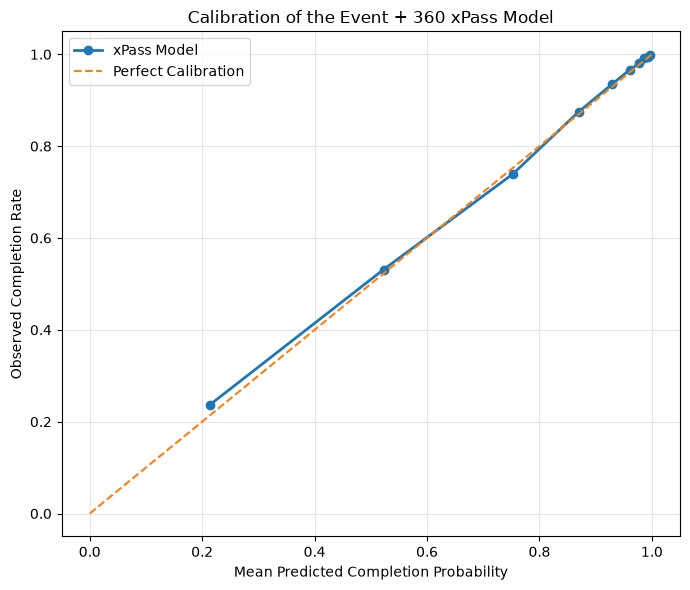

In [23]:
from sklearn.calibration import calibration_curve

fraction_positive, mean_predicted = calibration_curve(
    y_xpass_test,
    xpass_probabilities,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    mean_predicted,
    fraction_positive,
    marker="o",
    linewidth=2,
    label="xPass Model"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Completion Probability")
plt.ylabel("Observed Completion Rate")

plt.title(
    "Calibration of the Event + 360 xPass Model"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "xpass_calibration_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
calibration_table = pd.DataFrame({
    "mean_predicted_probability": mean_predicted,
    "observed_completion_rate": fraction_positive
})

calibration_table["absolute_gap"] = np.abs(
    calibration_table["observed_completion_rate"]
    - calibration_table["mean_predicted_probability"]
)

quantile_bins = pd.qcut(
    xpass_probabilities,
    q=10,
    duplicates="drop"
)

bin_counts = pd.Series(
    quantile_bins
).value_counts(
    sort=False
).values

bin_weights = (
    bin_counts
    / bin_counts.sum()
)

calibration_table["observations"] = bin_counts

calibration_table["weight"] = bin_weights

ece = np.sum(
    calibration_table["absolute_gap"]
    * calibration_table["weight"]
)

display(
    calibration_table.round(4)
)

print(
    f"Expected Calibration Error (ECE): {ece:.4f}"
)

calibration_table.to_csv(
    "xpass_calibration_results.csv",
    index=False
)

,mean_predicted_probability,observed_completion_rate,absolute_gap,observations,weight
0,0.2142,0.2372,0.0230,10431,0.1
1,0.5226,0.5313,0.0086,10430,0.1
2,0.7523,0.7390,0.0133,10431,0.1
3,0.8695,0.8745,0.0050,10430,0.1
4,0.9295,0.9353,0.0058,10431,0.1
5,0.9605,0.9661,0.0055,10430,0.1
6,0.9770,0.9802,0.0031,10431,0.1
7,0.9865,0.9912,0.0047,10430,0.1
8,0.9927,0.9951,0.0025,10430,0.1
9,0.9971,0.9986,0.0015,10431,0.1


Expected Calibration Error (ECE): 0.0073


In [25]:
xg_results = pd.read_csv(
    "xg_validation_results.csv"
)

print("xG results shape:", xg_results.shape)

display(xg_results)

xG results shape: (3, 4)


,Model,ROC_AUC,Log_Loss,Brier
0,Naive Baseline,0.500000,0.351902,0.099870
1,Our Event + 360 XGBoost,0.748721,0.312345,0.085960
2,StatsBomb xG,0.783904,0.285889,0.080815


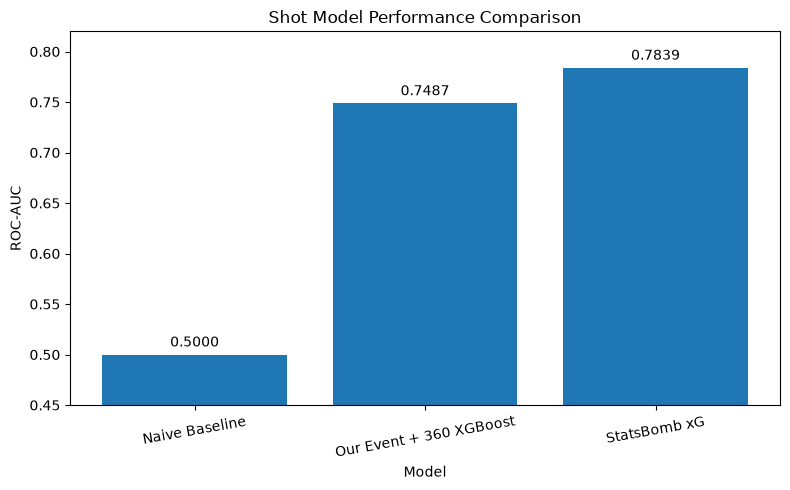

In [26]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    xg_results["Model"],
    xg_results["ROC_AUC"]
)

plt.ylabel("ROC-AUC")
plt.xlabel("Model")

plt.title(
    "Shot Model Performance Comparison"
)

plt.ylim(0.45, 0.82)

for bar, value in zip(
    bars,
    xg_results["ROC_AUC"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.008,
        f"{value:.4f}",
        ha="center"
    )

plt.xticks(rotation=10)

plt.tight_layout()

plt.savefig(
    "xg_model_auc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
evaluation_summary = pd.DataFrame({
    "Component": [
        "xPass Event Only",
        "xPass Event + 360",
        "Custom xG Event + 360",
        "StatsBomb xG",
        "Second-Half Actions",
        "Second-Half Progressive Passes",
        "Second-Half Pass Completion",
        "Second-Half Miscontrols",
        "Second-Half StatsBomb xG"
    ],

    "Model": [
        "XGBoost",
        "XGBoost",
        "XGBoost",
        "StatsBomb Benchmark",
        "Random Forest",
        "Linear Regression",
        "Linear Regression",
        "Linear Regression",
        "Linear Regression"
    ],

    "Evaluation_Metric": [
        "ROC-AUC",
        "ROC-AUC",
        "ROC-AUC",
        "ROC-AUC",
        "R²",
        "R²",
        "R²",
        "R²",
        "R²"
    ],

    "Score": [
        0.8886,
        0.9122,
        0.748721,
        0.783904,
        0.498625,
        0.317712,
        0.249906,
        0.156465,
        0.123944
    ],

    "Role_in_System": [
        "xPass baseline",
        "Contextual pass assessment",
        "Supporting shot experiment",
        "Operational shot-quality benchmark",
        "Future involvement forecast",
        "Future progression forecast",
        "Future passing-efficiency forecast",
        "Future ball-security forecast",
        "Future attacking-threat forecast"
    ]
})

display(
    evaluation_summary.round(4)
)

evaluation_summary.to_csv(
    "final_model_evaluation_summary.csv",
    index=False
)

,Component,Model,Evaluation_Metric,Score,Role_in_System
0,xPass Event Only,XGBoost,ROC-AUC,0.8886,xPass baseline
1,xPass Event + 360,XGBoost,ROC-AUC,0.9122,Contextual pass assessment
2,Custom xG Event + 360,XGBoost,ROC-AUC,0.7487,Supporting shot experiment
3,StatsBomb xG,StatsBomb Benchmark,ROC-AUC,0.7839,Operational shot-quality benchmark
4,Second-Half Actions,Random Forest,R²,0.4986,Future involvement forecast
5,Second-Half Progressive Passes,Linear Regression,R²,0.3177,Future progression forecast
6,Second-Half Pass Completion,Linear Regression,R²,0.2499,Future passing-efficiency forecast
7,Second-Half Miscontrols,Linear Regression,R²,0.1565,Future ball-security forecast
8,Second-Half StatsBomb xG,Linear Regression,R²,0.1239,Future attacking-threat forecast
